**Librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium

**Importación de Datos**


In [2]:
from google.colab import files
uploaded = files.upload()

Saving b. Modulo vehiculos.csv to b. Modulo vehiculos.csv
Saving Conteo_Vehiculos_CGT_BogotA1_D_C.csv to Conteo_Vehiculos_CGT_BogotA1_D_C.csv
Saving d. Modulo viajes.csv to d. Modulo viajes.csv
Saving OAB - PM2.5PME - La Ciudad.csv to OAB - PM2.5PME - La Ciudad.csv
Saving OAB - PM10PME - La Ciudad.csv to OAB - PM10PME - La Ciudad.csv
Saving Red_Semaforica_de_BogotA1_D.C..csv to Red_Semaforica_de_BogotA1_D.C..csv


**Datos semáforos**

In [3]:
df_semaforos = pd.read_csv('/content/Red_Semaforica_de_BogotA1_D.C..csv')
df_semaforos.head()


,X,Y,OBJECTID,ID,EXTERNO,DIRECCION,LOCALIDAD,EQUIPO,NUMEROINTERSECCIONES_POREQUIPO,UBICACIONEQUIPO,...,TOTALGRUPOSENALES,NUMEROFASES,GRUPOSVEHICULARES,GRUPOS_BRT,GRUPOSPEATONALES,GRUPOSSONOROS,GRUPOSCICLISTAS,CANTIDADCONTADORES,FUNCIONDETECTORES,ZONAAUTOMATICA
0,-74.052260,4.659426,1859,118,1007,AK 7 X CL 77,CHAPINERO,C900,SENCILLA,SI,...,9,3,"1,2,2A,3,5",NaN,"22,23,31",NaN,41,0,"Conteo, Brechas, Fases por demanda",1908
1,-74.052907,4.658773,1860,126,1008,AK 7 X CL 76,CHAPINERO,C900,DOBLE,SI,...,16,2,"1,12,12A,6",NaN,"21,312,36",NaN,"41,412",0,"Conteo, Brechas",1908
2,-74.053386,4.658028,1861,135,1008,AK 7 X CL 75,CHAPINERO,NO,DOBLE,NO,...,16,2,"2,2A,11,94",NaN,"22,211",NaN,42,0,"Conteo, Brechas",1908
3,-74.055421,4.654865,1862,152,1009,AK 7 X AC 72,CHAPINERO,C900,SENCILLA,SI,...,16,3,"1,2,2A,3,4,7,93",NaN,"21,22,23,24,31,32,33,34,293",NaN,NO,0,"Conteo, Brechas, Fases por demanda, Cola - Sig...",1909
4,-74.056556,4.652761,1863,162,1010,AK 7 X CL 70,CHAPINERO,C900,SENCILLA,SI,...,9,3,"1,2,2A,3,4",NaN,"22,23,24,31",NaN,NO,0,"Conteo, Brechas, Fases por demanda, Fases por ...",1909


In [4]:
df_semaforos['FUNCIONAMIENTO'].value_counts()

,count
FUNCIONAMIENTO,
BT-TF,970
BT-TA,622
CA-TA,612
RP-TF,538
R-TA,216
RP-TA,208
R-TF,198
CA-TF,20


In [5]:
df_semaforos['FUNCIONDETECTORES'].value_counts(dropna=False)

,count
FUNCIONDETECTORES,
NaN,1562
Activación de sonoro,370
"Conteo, Brechas",282
"Brechas, Fases por demanda",130
Brechas,112
...,...
"Fases por demanda, Cola - Siguiente Intersección, Activación de sonoro",2
"Conteo, Brechas, Cola, Fases por demanda peatonal",2
"Fase por demanda peatonal, Fases por demanda pearonal sonoro",2


<Axes: title={'center': 'Cantidad de intersecciones semafóricas por localidad'}, ylabel='LOCALIDAD'>

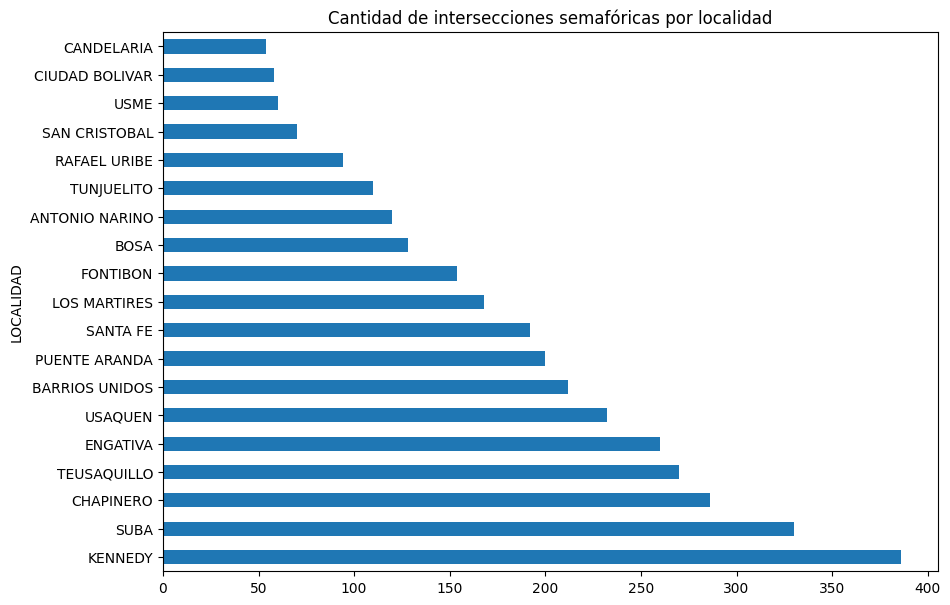

In [6]:
df_semaforos['LOCALIDAD'].value_counts().plot(kind='barh', figsize=(10,7), title='Cantidad de intersecciones semafóricas por localidad')

In [7]:
# Quitar espacios raros
for c in ['FUNCIONAMIENTO','FUNCIONDETECTORES','LOCALIDAD']:
    if c in df_semaforos.columns:
        df_semaforos[c] = df_semaforos[c].astype(str).str.strip().replace({'nan': np.nan})

# Separar prefijo y modo
df_semaforos[['CONTROL_NIVEL','MODO']] = df_semaforos['FUNCIONAMIENTO'].str.split('-', n=1, expand=True)

# Diccionarios para interpretación
control_desc = {
    'BT': 'Basado en tiempo',
    'CA': 'Central adaptativo',
    'RP': 'Responsivo ',
    'R' : 'Responsivo '
}
modo_desc = {
    'TA': 'Tráfico actuado',
    'TF': 'Tiempos fijos'
}

In [8]:
total = len(df_semaforos)

# ta vs tf
ta = (df_semaforos['MODO'] == 'TA').sum()
tf = (df_semaforos['MODO'] == 'TF').sum()
print(f'TA: {ta} ({ta/total:.2%}) | TF: {tf} ({tf/total:.2%})')

# estrategias (ej: BT)
fam_counts = df_semaforos['CONTROL_NIVEL'].value_counts().rename_axis('familia').to_frame('conteo')
fam_counts['%'] = fam_counts['conteo'] / total * 100
print(fam_counts)

# estrategias específicas (ej: CA-TA)
estrategias = df_semaforos['FUNCIONAMIENTO'].value_counts().rename_axis('estrategia').to_frame('conteo')
estrategias['%'] = estrategias['conteo'] / total * 100
estrategias


TA: 1658 (49.00%) | TF: 1726 (51.00%)
         conteo          %
familia                   
BT         1592  47.044917
RP          746  22.044917
CA          632  18.676123
R           414  12.234043


,conteo,%
estrategia,,
BT-TF,970,28.664303
BT-TA,622,18.380615
CA-TA,612,18.085106
RP-TF,538,15.898345
R-TA,216,6.382979
RP-TA,208,6.146572
R-TF,198,5.851064
CA-TF,20,0.591017


In [9]:
# tiene uso no nulo (programaciones ...)
df_semaforos['DETECTOR_USO'] = df_semaforos['FUNCIONDETECTORES'].notna()
print('Con uso programado de detectores:', df_semaforos['DETECTOR_USO'].sum(), f"({df_semaforos['DETECTOR_USO'].mean():.2%})")

# capacidades
keys = {
    'DET_CONTEO': 'Conteo',
    'DET_BRECHAS': 'Brechas',
    'DET_FASES_DEMANDA': 'Fases por demanda',
    'DET_COLA': 'Cola',
    'DET_SONORO': 'sonoro'
}
for newcol, token in keys.items():
    df_semaforos[newcol] = df_semaforos['FUNCIONDETECTORES'].str.contains(token, case=False, na=False)

capacidad_summary = df_semaforos[list(keys.keys())].mean().sort_values(ascending=False)*100
capacidad_summary = capacidad_summary.round(2).rename(lambda s: s.replace('DET_',''))
print('Capacidades de detectores (% de intersecciones):\n', capacidad_summary)


Con uso programado de detectores: 1822 (53.84%)
Capacidades de detectores (% de intersecciones):
 BRECHAS          34.40
CONTEO           24.88
SONORO           20.69
FASES_DEMANDA    18.68
COLA             10.93
dtype: float64


In [10]:
# intersecciones por localidad
loc_counts = df_semaforos['LOCALIDAD'].value_counts()
print(loc_counts)

# Composición de control por localidad
tabla_control_loc = (
    df_semaforos.pivot_table(index='LOCALIDAD', columns='FUNCIONAMIENTO', values='ID', aggfunc='count', fill_value=0)
      .pipe(lambda t: t.div(t.sum(axis=1), axis=0)*100)
      .round(2)
      .sort_index()
)
tabla_control_loc.head(21)


LOCALIDAD
KENNEDY           386
SUBA              330
CHAPINERO         286
TEUSAQUILLO       270
ENGATIVA          260
USAQUEN           232
BARRIOS UNIDOS    212
PUENTE ARANDA     200
SANTA FE          192
LOS MARTIRES      168
FONTIBON          154
BOSA              128
ANTONIO NARINO    120
TUNJUELITO        110
RAFAEL URIBE       94
SAN CRISTOBAL      70
USME               60
CIUDAD BOLIVAR     58
CANDELARIA         54
Name: count, dtype: int64


FUNCIONAMIENTO,BT-TA,BT-TF,CA-TA,CA-TF,R-TA,R-TF,RP-TA,RP-TF
LOCALIDAD,,,,,,,,
ANTONIO NARINO,13.33,8.33,10.00,0.00,6.67,21.67,13.33,26.67
BARRIOS UNIDOS,7.55,26.42,20.75,0.00,6.60,6.60,3.77,28.30
BOSA,34.38,54.69,6.25,0.00,0.00,0.00,0.00,4.69
CANDELARIA,22.22,25.93,0.00,0.00,0.00,11.11,18.52,22.22
CHAPINERO,8.39,8.39,39.16,1.40,7.69,2.80,7.69,24.48
CIUDAD BOLIVAR,17.24,6.90,41.38,3.45,0.00,0.00,17.24,13.79
ENGATIVA,26.92,33.08,26.15,0.77,0.77,2.31,6.92,3.08
FONTIBON,29.87,45.45,19.48,0.00,0.00,0.00,1.30,3.90
KENNEDY,17.62,59.07,8.81,1.04,5.70,2.07,3.63,2.07


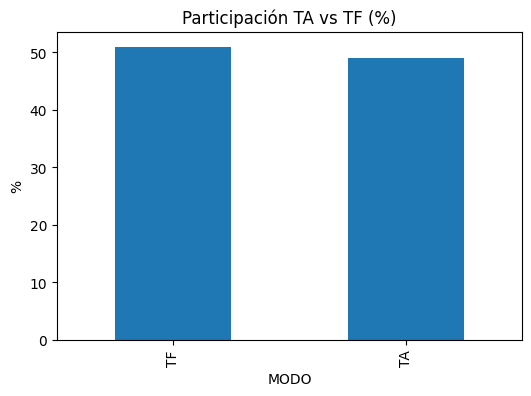

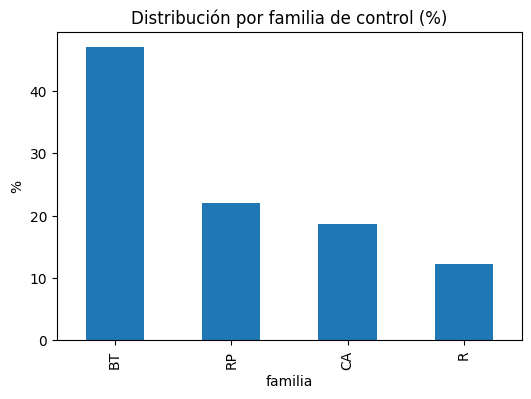

In [11]:
# TA vs TF
(df_semaforos['MODO'].value_counts(normalize=True)*100).plot(kind='bar', figsize=(6,4), title='Participación TA vs TF (%)')
plt.ylabel('%'); plt.show()

# Familias (estrategias)
(fam_counts['%']).plot(kind='bar', figsize=(6,4), title='Distribución por familia de control (%)')
plt.ylabel('%'); plt.show()




**Mapa con intersecciones y su tipo**

In [13]:
m = folium.Map(
    location=[4.65, -74.1],
    zoom_start=12,
    tiles="CartoDB positron"
)

color_map = {
    'CA-TA': 'limegreen',
    'CA-TF': 'forestgreen',
    'BT-TA': 'dodgerblue',
    'BT-TF': 'midnightblue',
    'RP-TA': 'orangered',
    'RP-TF': 'darkorange',
    'R-TA': 'orchid',
    'R-TF': 'indigo'
}

for _, r in df_semaforos.iterrows():
    try:
        folium.CircleMarker(
            location=[r['Y'], r['X']],
            radius=2,
            color=color_map.get(r['FUNCIONAMIENTO'], 'gray'),
            fill=True,
            fill_opacity=0.6
        ).add_to(m)

    except:
        pass

m

**Datos vehículos**

In [ ]:
df_vehiculos = pd.read_csv('/content/b. Modulo vehiculos.csv', encoding='cp1252', sep=';')
df_vehiculos.head()


,cod_vh,cod_viv,cod_hog,cod_utam_hg,zat_hg,cod_upl_hg,nom_mun_hg,estrato_hg,tipo_vehículo,cantidad,tipo_combustible,mun_matricula,tipo_placa,exento_pyp,modelo,propiedad_vh,key_hg,fexp_vh,Unnamed: 18
0,1,12156,5102,UTAM076,309,10,Bogotá D.C.,2,Automóvil,1,Sólo Gasolina,66001,Privada,No,2008,Este hogar,uuid:38d81220-9026-4f52-991a-f8915b447439,"81,2",NaN
1,2,3274,2130,UTAM056,703,29,Bogotá D.C.,2,Motocicleta,1,Sólo Gasolina,No aplica,Privada,NA (motos),2011,Este hogar,uuid:1807b7af-c09e-47af-9234-18f1a768cd61,"132,2",NaN
2,3,3274,2130,UTAM056,703,29,Bogotá D.C.,2,Motocicleta,1,Sólo Gasolina,No aplica,Privada,NA (motos),2020,Este hogar,uuid:1807b7af-c09e-47af-9234-18f1a768cd61,"132,2",NaN
3,4,4610,9050,UTAM060,685,29,Bogotá D.C.,1,Campero/Camioneta,1,Sólo Gasolina,11001,Pública,No,2014,Este hogar,uuid:6603181f-9cf9-4754-9aa4-f710acbef8e6,"2,9",NaN
4,5,3060,8972,UTAM058,939,27,Bogotá D.C.,2,Motocicleta,1,Sólo Gasolina,No aplica,Privada,NA (motos),2019,Este hogar,uuid:6511a0c7-545d-4af7-a784-8951c586decc,"200,0",NaN


In [ ]:
df_vehiculos['tipo_vehículo'].value_counts()


,count
tipo_vehículo,
Automóvil,6441
Bicicleta sin motor,4691
Motocicleta,4028
Campero/Camioneta,901
Bicicleta niños,329
Bicitaxi sin motor,190
Moto - carro,134
Taxi,115
Patineta eléctrica,92


In [ ]:
df_vehiculos['tipo_combustible'].value_counts()

,count
tipo_combustible,
Sólo Gasolina,11012
No aplica,5554
Diésel,348
GNV y gasolina,296
Híbrido (eléctrico- gasolina / diesel),92
Eléctrico,44
GNV,21
NS/NR,21
Otro,4


**Datos: Contéo de Vehículos**

In [ ]:
from shapely.geometry import Point

In [ ]:
df_conteo = pd.read_csv('/content/Conteo_Vehiculos_CGT_BogotA1_D_C.csv')
df_conteo.head()

,X,Y,FID,siteid,address,location,creationda,name
0,-74.043105,4.770023,1,1,Autopista norte x calle 192,Usaquen,2021/03/10 00:00:00+00,Autopista norte - calle 192
1,-74.105776,4.656926,2,5,Avenida calle 26 x carrera 68D,Fontibon,2021/03/10 00:00:00+00,Avenida calle 26 - carrera 68D El Tiempo
2,-74.137139,4.660699,3,9,Calle 17 x Avenida ciudad de Cali,Fontibon,2021/03/15 00:00:00+00,Calle 17 - Avenida ciudad de Cali
3,-74.052214,4.706307,4,10,Calle 127 x Autopista Norte,Usaquen,2021/03/16 00:00:00+00,Calle 127 - Autopista Norte
4,-74.094040,4.575284,5,12,Avenida 1 de Mayo x carrera 8A,Antonio Nariño,2021/03/16 00:00:00+00,Avenida 1 de Mayo x carrera 8A


In [ ]:
# columnas de geometría con coordenadas
df_semaforos['geometry'] = df_semaforos.apply(lambda row: Point(row['X'], row['Y']), axis=1)
df_conteo['geometry'] = df_conteo.apply(lambda row: Point(row['X'], row['Y']), axis=1)

# GeoDataFrames
gdf_semaforos = gpd.GeoDataFrame(df_semaforos, geometry='geometry', crs='EPSG:4326')
gdf_conteo = gpd.GeoDataFrame(df_conteo, geometry='geometry', crs='EPSG:4326')


In [ ]:
gdf_semaforos_3116 = gdf_semaforos.to_crs(3116)
gdf_conteo_3116    = gdf_conteo.to_crs(3116)

# inventario semafórico
gdf_semaforos_small = gdf_semaforos_3116[['FUNCIONAMIENTO', 'geometry']].copy()

# con distancia máxima de 300m
try:
    joined = gpd.sjoin_nearest(
        gdf_conteo_3116[['FID','siteid','name','geometry']],
        gdf_semaforos_small,
        how='left',
        distance_col='DISTANCIA_M',
        max_distance=300  # metros
    )
except TypeError:
    joined = gpd.sjoin_nearest(
        gdf_conteo_3116[['FID','siteid','name','geometry']],
        gdf_semaforos_small,
        how='left',
        distance_col='DISTANCIA_M'
    )
    joined = joined[joined['DISTANCIA_M'] <= 300]

In [ ]:
conteo_por_funcion = (
    joined
    .dropna(subset=['FUNCIONAMIENTO'])
    .groupby('FUNCIONAMIENTO', dropna=False)
    .size()
    .reset_index(name='num_puntos')
    .sort_values('num_puntos', ascending=False)
)

print(conteo_por_funcion)

  FUNCIONAMIENTO  num_puntos
2          CA-TA          14
3          RP-TA           6
1          BT-TF           4
0          BT-TA           2


In [ ]:
# Repetimos nearest sin filtro y marcamos cuáles superan 300 m
joined_all = gpd.sjoin_nearest(
    gdf_conteo_3116[['FID','siteid','name','geometry']],
    gdf_semaforos_small,
    how='left',
    distance_col='DISTANCIA_M'
)

sin_cercano = joined_all[joined_all['DISTANCIA_M'] > 300]
print(f"Puntos de conteo sin semáforo a ≤300 m: {len(sin_cercano)}")

resumen_dist = (
    joined
    .groupby('FUNCIONAMIENTO')['DISTANCIA_M']
    .agg(['count','mean','median','min','max'])
    .reset_index()
    .sort_values('mean')
)
print(resumen_dist)



Puntos de conteo sin semáforo a ≤300 m: 14
  FUNCIONAMIENTO  count        mean      median         min         max
2          CA-TA     14   95.103320  105.598882   13.563598  193.423164
1          BT-TF      4  147.565826  147.565826   23.840460  271.291191
3          RP-TA      6  192.493398  264.604131   34.510133  278.365930
0          BT-TA      2  248.831165  248.831165  248.831165  248.831165


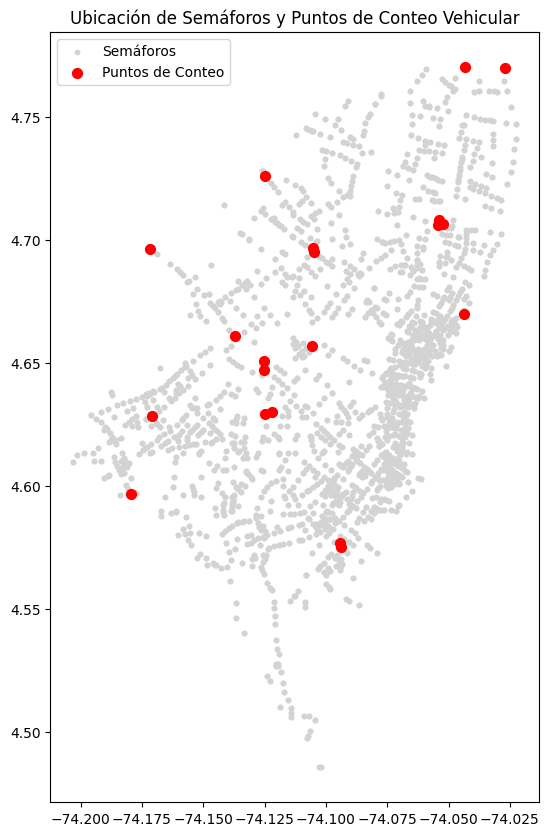

In [ ]:
# mapa puntos de conteo
gdf_conteo_plot = gdf_conteo.to_crs(epsg=4326)
gdf_semaforos_plot = gdf_semaforos.to_crs(epsg=4326)

# Gráfica
fig, ax = plt.subplots(figsize=(10, 10))
gdf_semaforos_plot.plot(ax=ax, color='lightgrey', markersize=10, label='Semáforos')
gdf_conteo_plot.plot(ax=ax, color='red', markersize=50, label='Puntos de Conteo')
plt.legend()
plt.title("Ubicación de Semáforos y Puntos de Conteo Vehicular")
plt.show()


**Datos PM10**

In [ ]:
df_pm10 = pd.read_csv('/content/OAB - PM10PME - La Ciudad.csv')
df_pm10.head()
df_pm10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Periodo  139 non-null    object 
 1   CSE      108 non-null    float64
 2   MOV2     41 non-null     float64
 3   SUB      129 non-null    float64
 4   USM      41 non-null     float64
 5   CDAR     123 non-null    float64
 6   TUN      134 non-null    float64
 7   FTB      83 non-null     float64
 8   USQ      116 non-null    float64
 9   GYR      133 non-null    float64
 10  KEN      128 non-null    float64
 11  LFR      125 non-null    float64
 12  MAM      124 non-null    object 
 13  PTE      125 non-null    float64
 14  CBV      41 non-null     float64
 15  JAZ      42 non-null     float64
 16  BOL      38 non-null     float64
 17  BOS      0 non-null      float64
 18  COL      41 non-null     float64
 19  SCR      132 non-null    float64
 20  MOV      31 non-null     float64
dtypes: float64(19), 

**Datos PM2.5**

In [ ]:
df_pm25 = pd.read_csv('/content/OAB - PM2.5PME - La Ciudad.csv')
df_pm25.head()
df_pm25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Periodo  142 non-null    object 
 1   MOV      31 non-null     float64
 2   CBV      42 non-null     float64
 3   MAM      127 non-null    float64
 4   JAZ      51 non-null     float64
 5   PTE      97 non-null     float64
 6   MOV2     41 non-null     float64
 7   SCR      122 non-null    float64
 8   CSE      107 non-null    float64
 9   USM      41 non-null     float64
 10  SUB      127 non-null    float64
 11  CDAR     129 non-null    float64
 12  BOL      46 non-null     float64
 13  TUN      138 non-null    float64
 14  FTB      77 non-null     float64
 15  USQ      123 non-null    float64
 16  GYR      119 non-null    float64
 17  BOS      0 non-null      float64
 18  COL      42 non-null     float64
 19  KEN      134 non-null    float64
 20  LFR      124 non-null    float64
dtypes: float64(20), 

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# coordenadas de las estaciones
estaciones_coords = {
    'GYR': (-74.04414, 4.78375),   # Guaymaral
    'SUB': (-74.09351, 4.76125),   # Suba
    'USQ': (-74.03042, 4.71035),   # Usaquén
    'SUB': (-74.09351, 4.76125),   # Suba
    'BOL': (-74.12589, 4.73525),   # Bolivia
    'LFR': (-74.08248, 4.69074),   # Las Ferias
    'CDAR': (-74.08453, 4.65847),  # Centro de Alto Rendimiento
    'MOV': (-74.06156, 4.64514),   # Estación móvil 7ma
    'MAM': (-74.06697, 4.62547),   # MinAmbiente
    'FTB': (-74.14382, 4.67813),   # Fontibón
    'PTE': (-74.11738, 4.63178),   # Puente Aranda
    'KEN': (-74.16133, 4.62505),   # Kennedy
    'CSE': (-74.14850, 4.59583),   # Carvajal-Sevillana
    'TUN': (-74.13100, 4.57616),   # Tunal
    'SCR': (-74.08374, 4.57255),   # San Cristóbal
    'JAZ': (-74.11494, 4.60850),   # El Jazmín
    'USM': (-74.11714, 4.53206),   # Usme
    'BOS': (-74.20406, 4.60561),   # Bosa
    'CBV': (-74.16628, 4.57781),   # Ciudad Bolívar
    'COL': (-74.06947, 4.73719),   # Colina
    'MOV2': (-74.14850, 4.66799)   # Móvil Fontibón
}

In [ ]:
# estaciones a DataFrame
df_estaciones = pd.DataFrame([
    {"estacion": est, "geometry": Point(lon, lat)}
    for est, (lon, lat) in estaciones_coords.items()
])

# Convertir a GeoDataFrame con CRS geográfico
gdf_estaciones = gpd.GeoDataFrame(df_estaciones, geometry="geometry", crs="EPSG:4326")
gdf_estaciones = gdf_estaciones.to_crs(epsg=3116)

In [ ]:
#  columna funcionamiento
gdf_semaforos_clean = gdf_semaforos.to_crs(3116)[['FUNCIONAMIENTO', 'geometry']].copy()

# por distancia
try:
    estaciones_joined = gpd.sjoin_nearest(
        gdf_estaciones,
        gdf_semaforos_clean,
        how='left',
        distance_col='DISTANCIA_M',
        max_distance=5000
    )
except:
    estaciones_joined = gpd.sjoin_nearest(
        gdf_estaciones,
        gdf_semaforos_clean,
        how='left',
        distance_col='DISTANCIA_M'
    )
    estaciones_joined = estaciones_joined[estaciones_joined['DISTANCIA_M'] <= 5000]



In [ ]:
df_pm25 = df_pm25.drop(columns=["Periodo"], errors='ignore')
df_pm10 = df_pm10.drop(columns=["Periodo"], errors='ignore')

pm25_mean = df_pm25.mean(numeric_only=True).to_dict()
pm10_mean = df_pm10.mean(numeric_only=True).to_dict()

# promedios al GeoDataFrame
estaciones_joined['PM25'] = estaciones_joined['estacion'].map(pm25_mean)
estaciones_joined['PM10'] = estaciones_joined['estacion'].map(pm10_mean)


In [ ]:
# promedio de contaminantes por tipo de semáforo
resumen_pm = (
    estaciones_joined
    .dropna(subset=['FUNCIONAMIENTO'])
    .groupby('FUNCIONAMIENTO')[['PM25','PM10']]
    .mean()
    .reset_index()
    .sort_values('PM25')  #ordenar por menor PM25
)

print(resumen_pm)

  FUNCIONAMIENTO       PM25       PM10
0          BT-TA  14.745780  31.225696
5          RP-TF  15.556603  36.801161
1          BT-TF  16.031270  30.520388
4          RP-TA  17.521429  39.651220
3           R-TA  18.711194  42.181717
2          CA-TA  18.989372  43.556581


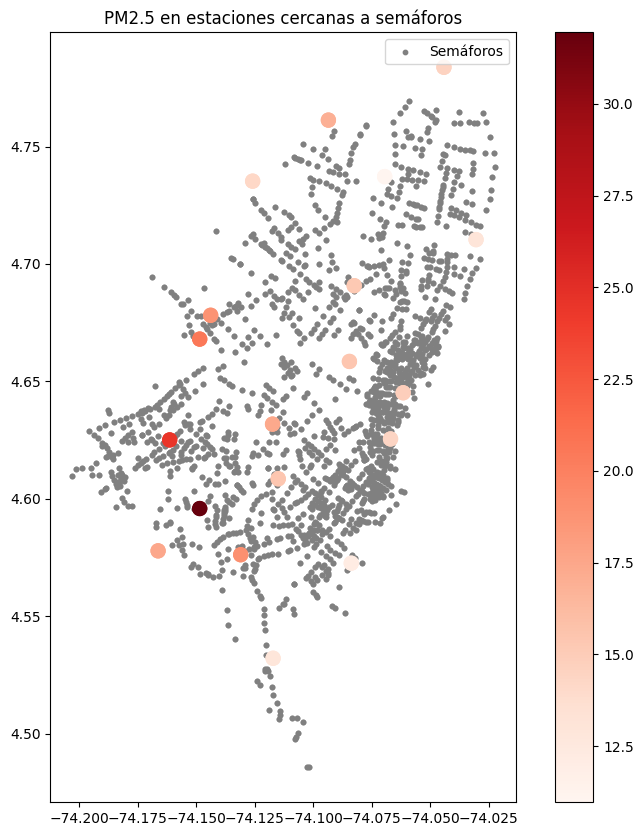

In [ ]:
gdf_plot_est = estaciones_joined.to_crs(4326)
gdf_plot_sem = gdf_semaforos_clean.to_crs(4326)

# Mapa
fig, ax = plt.subplots(figsize=(10,10))
gdf_plot_sem.plot(ax=ax, markersize=10, color="gray", label="Semáforos")
gdf_plot_est.plot(ax=ax, markersize=100, column='PM25', cmap='Reds', legend=True)
plt.title("PM2.5 en estaciones cercanas a semáforos")
plt.legend()
plt.show()


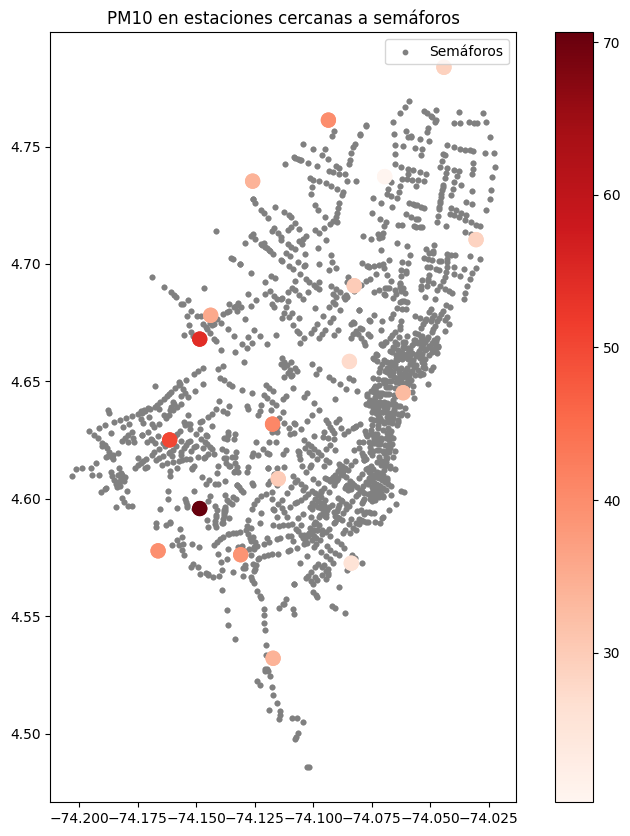

In [ ]:
gdf_plot_est = estaciones_joined.to_crs(4326)
gdf_plot_sem = gdf_semaforos_clean.to_crs(4326)

# Mapa
fig, ax = plt.subplots(figsize=(10,10))
gdf_plot_sem.plot(ax=ax, markersize=10, color="gray", label="Semáforos")
gdf_plot_est.plot(ax=ax, markersize=100, column='PM10', cmap='Reds', legend=True)
plt.title("PM10 en estaciones cercanas a semáforos")
plt.legend()
plt.show()

In [ ]:
from folium import plugins
import branca.colormap as cm

In [ ]:
# Estaciones GeoDataFrame
gdf_estaciones = gpd.GeoDataFrame(
    [{"estacion": k, "geometry": Point(v[0], v[1])} for k, v in estaciones_coords.items()],
    geometry="geometry", crs="EPSG:4326"
)

# semáforos
gdf_semaforos = gdf_semaforos.to_crs(4326)

est_3116 = gdf_estaciones.to_crs(3116)
sem_3116 = gdf_semaforos[['FUNCIONAMIENTO','geometry']].to_crs(3116)

# distancia
try:
    est_join = gpd.sjoin_nearest(
        est_3116, sem_3116, how='left', distance_col='DISTANCIA_M', max_distance=2000
    )
except TypeError:
    est_join = gpd.sjoin_nearest(est_3116, sem_3116, how='left', distance_col='DISTANCIA_M')
    est_join = est_join[est_join['DISTANCIA_M'] <= 2000]

# para mapas
est_join_4326 = est_join.to_crs(4326)
sem_4326 = sem_3116.to_crs(4326)

In [ ]:
est_join_4326['PM25'] = est_join_4326['estacion'].map(pm25_mean)
est_join_4326['PM10'] = est_join_4326['estacion'].map(pm10_mean)

# Estaciones con y sin semáforo cercano (para contraste)
# (hacemos un join sin filtro para etiquetar las >1 km como "sin cercano")
est_all = gpd.sjoin_nearest(est_3116, sem_3116, how='left', distance_col='DISTANCIA_M_ALL').to_crs(4326)
est_all['PM25'] = est_all['estacion'].map(pm25_mean)
est_all['PM10'] = est_all['estacion'].map(pm10_mean)

est_con = est_all[est_all['DISTANCIA_M_ALL'] <= 2000].copy()
est_sin = est_all[est_all['DISTANCIA_M_ALL'] > 2000].copy()


In [ ]:
def add_pm_layer(m, gdf_points, value_col, layer_name):

    vmin = float(gdf_points[value_col].min())
    vmax = float(gdf_points[value_col].max())
    if not (vmin < vmax):
        vmin, vmax = 0.0, 1.0
    colormap = cm.linear.YlOrRd_09.scale(vmin, vmax)
    colormap.caption = f"{value_col} (µg/m³)"
    colormap.add_to(m)

    fg = folium.FeatureGroup(name=layer_name, show=True)
    for _, r in gdf_points.dropna(subset=[value_col]).iterrows():
        folium.CircleMarker(
            location=[r.geometry.y, r.geometry.x],
            radius=10,
            fill=True,
            fill_opacity=0.9,
            opacity=0.7,
            weight=1,
            color=colormap(r[value_col])
        ).add_child(
            folium.Popup(f"{r.get('estacion','(s/est)')}<br>{value_col}: {round(r[value_col],2)}<br>"
                         f"Func.: {r.get('FUNCIONAMIENTO','-')}<br>"
                         f"Dist. (m): {round(r.get('DISTANCIA_M', r.get('DISTANCIA_M_ALL', float('nan'))),1)}",
                         max_width=250)
        ).add_to(fg)
    fg.add_to(m)

def add_semaphore_layers(m, gdf_semaforos, sample_per_layer=250):

    for tipo, g in gdf_semaforos.dropna(subset=['FUNCIONAMIENTO']).groupby('FUNCIONAMIENTO'):
        if len(g) > sample_per_layer:
            g = g.sample(sample_per_layer, random_state=42)
        fg = folium.FeatureGroup(name=f"Semáforos {tipo}", show=False)
        for _, r in g.iterrows():
            folium.CircleMarker(
                location=[r.geometry.y, r.geometry.x],
                radius=2, color="#555", fill=True, fill_opacity=0.6
            ).add_to(fg)
        fg.add_to(m)

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [ ]:
pm25 = pd.read_csv("/content/OAB - PM10PME - La Ciudad.csv")
pm10 = pd.read_csv("/content/OAB - PM2.5PME - La Ciudad.csv")

# Función para pasar wide -> long
def wide_to_long(df, pollutant_name):
    df = df.copy()
    # Estandariza el nombre de periodo
    if 'Periodo' in df.columns:
        df['Periodo'] = pd.to_datetime(df['Periodo'], errors='coerce', utc=True)
    else:
        raise ValueError("No encuentro la columna 'Periodo' en el dataset de " + pollutant_name)

    # columnas estación
    station_cols = [c for c in df.columns if c != 'Periodo']
    df_long = df.melt(id_vars='Periodo', value_vars=station_cols,
                      var_name='estacion', value_name=pollutant_name)

    df_long[pollutant_name] = pd.to_numeric(df_long[pollutant_name], errors='coerce')
    # mensual
    df_long['mes'] = df_long['Periodo'].dt.to_period('M').dt.to_timestamp()
    return df_long

pm25_long = wide_to_long(pm25, 'PM25')
pm10_long = wide_to_long(pm10, 'PM10')

#  tabla combinada por estación fecha
pm = pd.merge(pm25_long, pm10_long, on=['Periodo','mes','estacion'], how='outer')


/tmp/ipython-input-2348858491.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_long['mes'] = df_long['Periodo'].dt.to_period('M').dt.to_timestamp()
/tmp/ipython-input-2348858491.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_long['mes'] = df_long['Periodo'].dt.to_period('M').dt.to_timestamp()


In [ ]:
gdf_est = gpd.GeoDataFrame(
    [{"estacion": k, "geometry": Point(v[0], v[1])} for k, v in estaciones_coords.items()],
    geometry="geometry", crs="EPSG:4326"
)


gdf_est_3116 = gdf_est.to_crs(3116)
gdf_sem_3116 = gdf_semaforos[['FUNCIONAMIENTO','geometry']].to_crs(3116)

# vecino más cercano
try:
    est_sem = gpd.sjoin_nearest(
        gdf_est_3116, gdf_sem_3116, how='left',
        distance_col='dist_m', max_distance=1000
    )
except TypeError:
    est_sem = gpd.sjoin_nearest(
        gdf_est_3116, gdf_sem_3116, how='left',
        distance_col='dist_m'
    )
    est_sem = est_sem[est_sem['dist_m'] <= 1000]

# tabla estación tipo semáforo
est_tipo = est_sem[['estacion','FUNCIONAMIENTO','dist_m']].copy()


In [ ]:
pm_tipo = pm.merge(est_tipo, on='estacion', how='left')

# estaciones con semáforo
pm_tipo = pm_tipo[~pm_tipo['FUNCIONAMIENTO'].isna()].copy()


pm_tipo = pm_tipo.sort_values(['estacion','mes'])
pm_tipo['PM25_roll3'] = pm_tipo.groupby('estacion')['PM25'].transform(lambda s: s.rolling(3, min_periods=1).mean())
pm_tipo['PM10_roll3'] = pm_tipo.groupby('estacion')['PM10'].transform(lambda s: s.rolling(3, min_periods=1).mean())


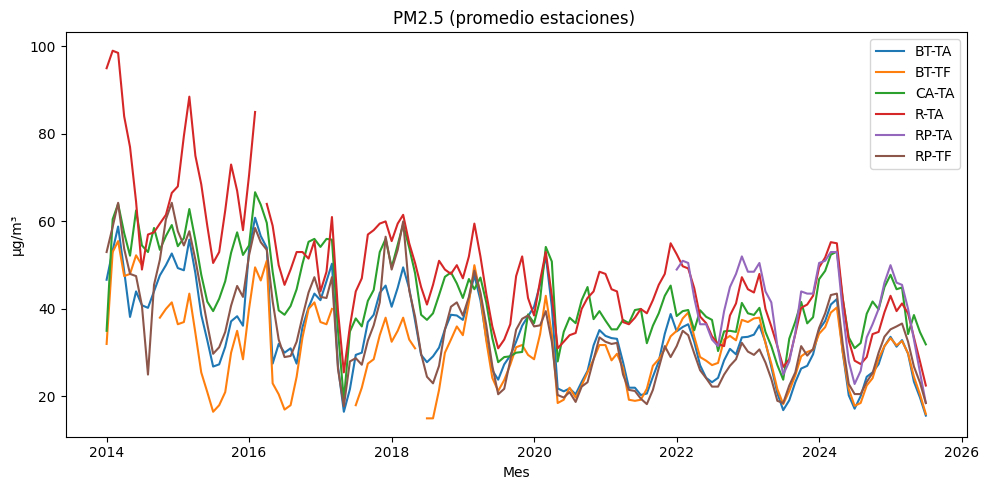

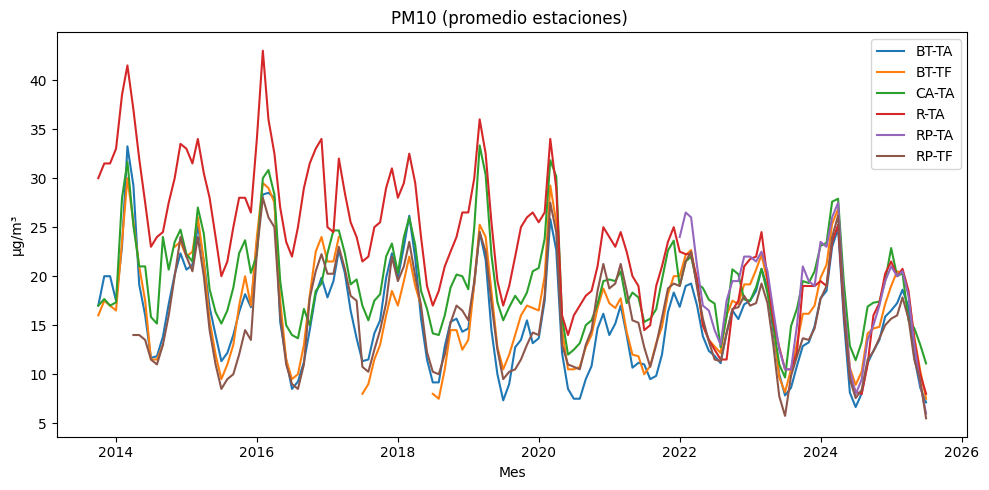

In [ ]:
# Promedio mensual por tipo
mensual_tipo = (
    pm_tipo.groupby(['mes','FUNCIONAMIENTO'])[['PM25','PM10','PM25_roll3','PM10_roll3']]
    .mean().reset_index()
)

# Gráfico PM2.5
plt.figure(figsize=(10,5))
for tipo, g in mensual_tipo.groupby('FUNCIONAMIENTO'):
    plt.plot(g['mes'], g['PM25_roll3'], label=str(tipo))
plt.title("PM2.5 (promedio estaciones) ")
plt.xlabel("Mes")
plt.ylabel("µg/m³")
plt.legend()
plt.tight_layout()
plt.show()

# Gráfico PM10
plt.figure(figsize=(10,5))
for tipo, g in mensual_tipo.groupby('FUNCIONAMIENTO'):
    plt.plot(g['mes'], g['PM10_roll3'], label=str(tipo))
plt.title("PM10 (promedio estaciones) ")
plt.xlabel("Mes")
plt.ylabel("µg/m³")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Codificar el tiempo como número (meses desde el inicio)
t0 = pm_tipo['mes'].min()

pm_tipo['t'] = ((pm_tipo['mes'].dt.year - t0.year) * 12 + pm_tipo['mes'].dt.month - t0.month).astype(float)

# Estimar pendiente por estación (para PM2.5 y PM10), con OLS simple
def slope_by_station(df, ycol):
    rows = []
    for est, g in df[['estacion','t',ycol,'FUNCIONAMIENTO']].dropna().groupby('estacion'):
        if g[ycol].notna().sum() >= 4:
            X = sm.add_constant(g['t'].values)
            y = g[ycol].values
            model = sm.OLS(y, X).fit()
            rows.append({
                'estacion': est,
                'FUNCIONAMIENTO': g['FUNCIONAMIENTO'].iloc[0],
                f'slope_{ycol}': model.params[1],   # cambio por mes (µg/m³ / mes)
                f'pval_{ycol}': model.pvalues[1] if len(model.pvalues)>1 else np.nan,
                f'r2_{ycol}': model.rsquared
            })
    return pd.DataFrame(rows)

slopes25 = slope_by_station(pm_tipo, 'PM25')
slopes10 = slope_by_station(pm_tipo, 'PM10')

slopes = slopes25.merge(slopes10, on=['estacion','FUNCIONAMIENTO'], how='outer')
print(slopes.sort_values('slope_PM25'))


   estacion FUNCIONAMIENTO  slope_PM25     pval_PM25   r2_PM25  slope_PM10  \
1       CBV          RP-TA   -0.263682  4.319565e-03  0.097365   -0.179935   
16      USM           R-TA   -0.247138  1.503816e-03  0.119007   -0.062980   
12      PTE          RP-TF   -0.245199  2.160304e-33  0.443313   -0.063845   
7       KEN           R-TA   -0.212800  2.643182e-23  0.323044   -0.094769   
5       FTB          BT-TF   -0.192895  1.069394e-16  0.343594   -0.005771   
0       BOL          CA-TA   -0.187180  1.733382e-02  0.074140   -0.089120   
14      SUB          BT-TA   -0.177551  7.871809e-23  0.315207   -0.064760   
6       JAZ          BT-TF   -0.164883  1.867284e-02  0.065620   -0.022004   
17      USQ          CA-TA   -0.152979  3.530893e-20  0.308501   -0.026247   
4       CSE          CA-TA   -0.148150  7.368670e-09  0.144953    0.017090   
9       MAM          RP-TF   -0.131942  5.539018e-17  0.252034   -0.022334   
8       LFR          CA-TA   -0.129921  7.002852e-15  0.217160  